-> 1/8 Đang chạy PCA...
-> 2/8 Đang chạy MDS...
-> 3/8 Đang chạy Sammon Mapping...
-> 4/8 Đang chạy Isomap...
-> 5/8 Đang chạy LLE...
-> 6/8 Đang chạy t-SNE...
-> 7/8 Đang huấn luyện Autoencoder (Iris)...
-> 8/8 Đang huấn luyện SOM (Iris)...


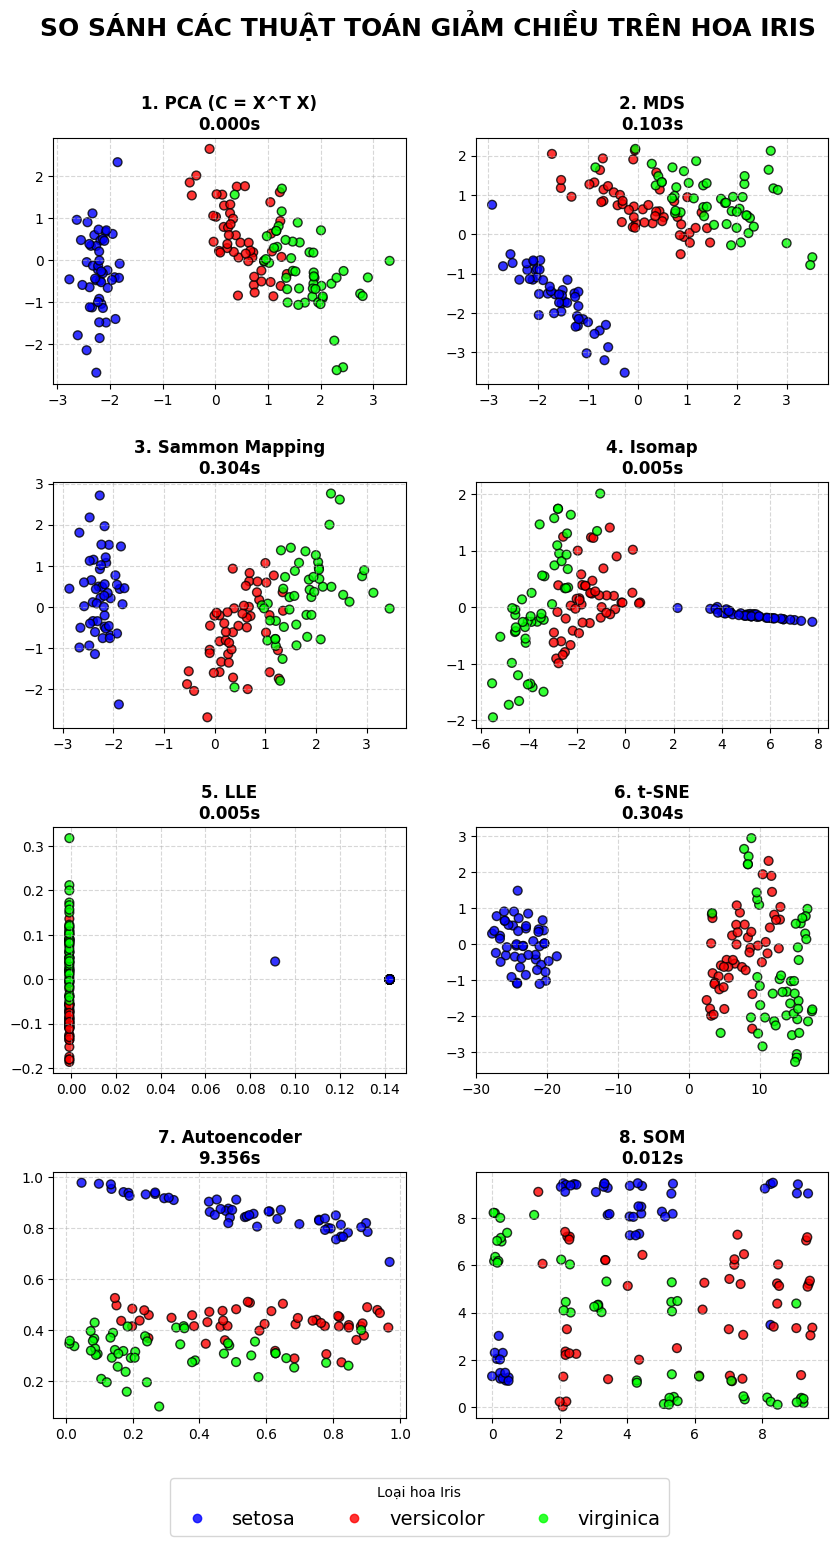

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import eigh
from scipy.spatial.distance import pdist
from scipy.optimize import minimize
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding, TSNE
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from minisom import MiniSom
import warnings

warnings.filterwarnings('ignore')


# KHỞI TẠO VÀ CHUẨN HÓA DỮ LIỆU IRIS

iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_std = StandardScaler().fit_transform(X)
exec_times = {}


# NHÓM 1: TUYẾN TÍNH

print("-> 1/8 Đang chạy PCA...")
t0 = time.time()
cov = np.matmul(X_std.T, X_std)
values, vectors = eigh(cov)
sorted_index = np.argsort(values)[::-1]
vecs_top2 = vectors[:, sorted_index[:2]]
pca_res = np.matmul(X_std, vecs_top2)
exec_times['PCA'] = max(0, time.time() - t0)

print("-> 2/8 Đang chạy MDS...")
t0 = time.time()
mds_res = MDS(n_components=2, random_state=42).fit_transform(X_std)
exec_times['MDS'] = max(0, time.time() - t0)


# NHÓM 2: PHI TUYẾN

print("-> 3/8 Đang chạy Sammon Mapping...")
t0 = time.time()
D = np.maximum(pdist(X_std, 'euclidean'), 1e-7)
c = np.sum(D)
def sammon_stress(Y): 
    diff = ((D - pdist(Y.reshape(-1, 2), 'euclidean'))**2) / D
    return np.sum(diff) / c
sammon_res = minimize(sammon_stress, PCA(n_components=2).fit_transform(X_std).flatten(), method='L-BFGS-B', options={'maxiter': 200}).x.reshape(-1, 2)
exec_times['Sammon'] = max(0, time.time() - t0)

print("-> 4/8 Đang chạy Isomap...")
t0 = time.time()
iso_res = Isomap(n_components=2, n_neighbors=5).fit_transform(X_std)
exec_times['Isomap'] = max(0, time.time() - t0)

print("-> 5/8 Đang chạy LLE...")
t0 = time.time()
lle_res = LocallyLinearEmbedding(n_components=2, n_neighbors=10).fit_transform(X_std)
exec_times['LLE'] = max(0, time.time() - t0)

# NHÓM 3: MẠNG NƠ-RON

print("-> 6/8 Đang chạy t-SNE...")
t0 = time.time()
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_std)
exec_times['t-SNE'] = max(0, time.time() - t0)

print("-> 7/8 Đang huấn luyện Autoencoder (Iris)...")
inputs = Input(shape=(4,))

# --- ENCODER (Hạ nấc từ từ cho dữ liệu 4 chiều) ---
# Tăng nhẹ lên 16 để bung thông tin, sau đó nén xuống 8
enc1 = Dense(16, activation='relu')(inputs)
enc2 = Dense(8, activation='relu')(enc1)

# --- BOTTLENECK (Nút thắt) ---
# Dùng sigmoid theo ý bạn để ép các điểm dữ liệu tụ lại trong một chiếc hộp vuông [0, 1]
encoded = Dense(2, activation='sigmoid')(enc2) 

# --- DECODER (Giải nén đối xứng) ---
dec1 = Dense(8, activation='relu')(encoded)
dec2 = Dense(16, activation='relu')(dec1)

# Lớp Output trả về đúng 4 chiều gốc
decoded = Dense(4, activation='linear')(dec2)

autoencoder = Model(inputs, decoded)
encoder = Model(inputs, encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_std, X_std, epochs=150, batch_size=16, verbose=0)

ae_res = encoder.predict(X_std, verbose=0)
exec_times['Autoencoder'] = max(0, time.time() - t0)

print("-> 8/8 Đang huấn luyện SOM (Iris)...")
t0 = time.time()
som = MiniSom(x=10, y=10, input_len=4, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_std)
som.train_random(X_std, 500) 
som_res = np.array([som.winner(x) for x in X_std]) + np.random.rand(150, 2) * 0.5
exec_times['SOM'] = max(0, time.time() - t0)

# ==========================================
# TRỰC QUAN HÓA (ĐÃ FIX BỐ CỤC 4x2)
# ==========================================
fig, axs = plt.subplots(4, 2, figsize=(10, 16)) # Lưới 4 hàng, 2 cột
fig.subplots_adjust(hspace=0.4, wspace=0.2, bottom=0.08)

def plot_scatter(ax, data, title):
    # Dùng cmap='brg' vì Iris có 3 class tương ứng với Xanh dương, Đỏ, Xanh lá
    scatter = ax.scatter(data[:, 0], data[:, 1], c=y, cmap='brg', alpha=0.8, edgecolor='k', s=40)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    return scatter

# Hàng 1
plot_scatter(axs[0, 0], pca_res, f"1. PCA (C = X^T X)\n{exec_times['PCA']:.3f}s")
plot_scatter(axs[0, 1], mds_res, f"2. MDS\n{exec_times['MDS']:.3f}s")

# Hàng 2
plot_scatter(axs[1, 0], sammon_res, f"3. Sammon Mapping\n{exec_times['Sammon']:.3f}s")
plot_scatter(axs[1, 1], iso_res, f"4. Isomap\n{exec_times['Isomap']:.3f}s")

# Hàng 3
plot_scatter(axs[2, 0], lle_res, f"5. LLE\n{exec_times['LLE']:.3f}s")
scatter = plot_scatter(axs[2, 1], tsne_res, f"6. t-SNE\n{exec_times['t-SNE']:.3f}s")

# Hàng 4
plot_scatter(axs[3, 0], ae_res, f"7. Autoencoder\n{exec_times['Autoencoder']:.3f}s")
plot_scatter(axs[3, 1], som_res, f"8. SOM\n{exec_times['SOM']:.3f}s")

# Tùy chỉnh Legend
handles, _ = scatter.legend_elements()
fig.legend(handles, target_names, loc='lower center', ncol=3, fontsize=14, title="Loại hoa Iris")
plt.suptitle("SO SÁNH CÁC THUẬT TOÁN GIẢM CHIỀU TRÊN HOA IRIS", fontsize=18, fontweight='bold', y=0.96)
plt.show()

Đang tải dữ liệu MNIST...
-> 1/8 Đang chạy PCA...
-> 2/8 Đang chạy MDS...
-> 3/8 Đang chạy Sammon Mapping (Sẽ hơi lâu một chút)...
-> 4/8 Đang chạy Isomap...
-> 5/8 Đang chạy LLE...
-> 6/8 Đang chạy t-SNE...
-> 7/8 Đang huấn luyện Autoencoder (MNIST)...


2026-03-15 21:04:55.046333: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:04:55.046378: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:04:55.046436: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:04:55.046449: I external/l

-> 8/8 Đang huấn luyện SOM (MNIST)...


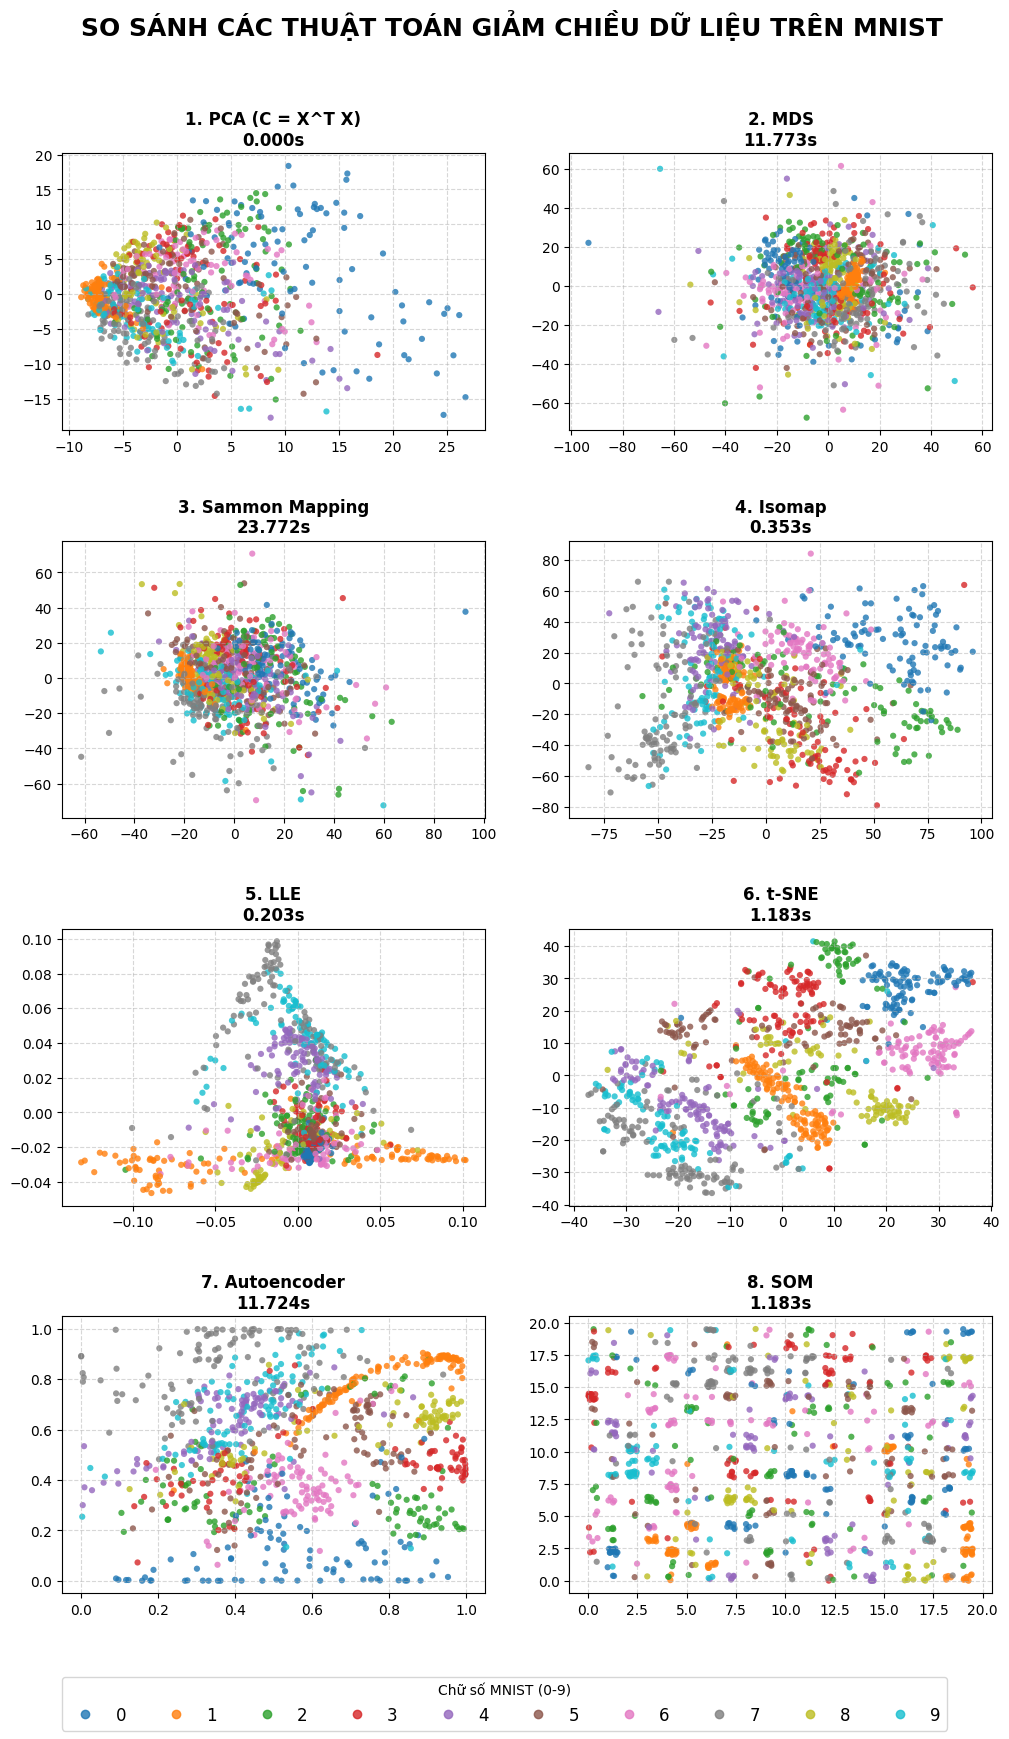

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import eigh
from scipy.spatial.distance import pdist
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding, TSNE
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist
from minisom import MiniSom
import warnings

warnings.filterwarnings('ignore')


# KHỞI TẠO VÀ CHUẨN HÓA DỮ LIỆU MNIST
print("Đang tải dữ liệu MNIST...")
(x_train, y_train), _ = mnist.load_data()

# Lấy 1000 ảnh nhiều hơn ở các thuật toán phi tuyến máy chyaj ko nổi
N_SAMPLES = 1000
X = x_train[:N_SAMPLES].reshape(N_SAMPLES, 784).astype('float32') / 255.
y = y_train[:N_SAMPLES]
target_names = [str(i) for i in range(10)]

X_std = StandardScaler().fit_transform(X)
exec_times = {}


# NHÓM 1: TUYẾN TÍNH

print("-> 1/8 Đang chạy PCA")
t0 = time.time()
cov = np.matmul(X_std.T, X_std)
values, vectors = eigh(cov)
sorted_index = np.argsort(values)[::-1]
vecs_top2 = vectors[:, sorted_index[:2]]
pca_res = np.matmul(X_std, vecs_top2)
exec_times['PCA'] = max(0, time.time() - t0) 

print("-> 2/8 Đang chạy MDS")
t0 = time.time()
mds_res = MDS(n_components=2, random_state=42).fit_transform(X_std)
exec_times['MDS'] = max(0, time.time() - t0)


# NHÓM 2: PHI TUYẾN

print("-> 3/8 Đang chạy Sammon Mapping")
t0 = time.time()
D = np.maximum(pdist(X_std, 'euclidean'), 1e-7)
c = np.sum(D)
def sammon_stress(Y): 
    diff = ((D - pdist(Y.reshape(-1, 2), 'euclidean'))**2) / D
    return np.sum(diff) / c
sammon_res = minimize(sammon_stress, PCA(n_components=2).fit_transform(X_std).flatten(), method='L-BFGS-B', options={'maxiter': 200}).x.reshape(-1, 2)
exec_times['Sammon'] = max(0, time.time() - t0)

print("-> 4/8 Đang chạy Isomap...")
t0 = time.time() # Reset lại t0 ngay sát lúc chạy
iso_res = Isomap(n_components=2, n_neighbors=5).fit_transform(X_std)
exec_times['Isomap'] = max(0, time.time() - t0) # Fix triệt để số âm

print("-> 5/8 Đang chạy LLE...")
t0 = time.time()
lle_res = LocallyLinearEmbedding(n_components=2, n_neighbors=10).fit_transform(X_std)
exec_times['LLE'] = max(0, time.time() - t0)

# ==========================================
# NHÓM 3: MẠNG NƠ-RON
# ==========================================
print("-> 6/8 Đang chạy t-SNE...")
t0 = time.time()
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_std)
exec_times['t-SNE'] = max(0, time.time() - t0)

print("-> 7/8 Đang huấn luyện Autoencoder (MNIST)...")
t0 = time.time()
inputs = Input(shape=(784,))

# --- ENCODER (Hạ cánh từ từ) ---
enc1 = Dense(512, activation='relu')(inputs)
enc2 = Dense(128, activation='relu')(enc1)
encoded = Dense(2, activation='sigmoid')(enc2) 
dec1 = Dense(128, activation='relu')(encoded)
dec2 = Dense(512, activation='relu')(dec1)

# Lớp Output BẮT BUỘC phải là 'linear' vì X_std của chúng ta chứa các số âm (đã chuẩn hóa StandardScaler)
decoded = Dense(784, activation='linear')(dec2)

autoencoder = Model(inputs, decoded)
encoder = Model(inputs, encoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_std, X_std, epochs=50, batch_size=32, verbose=0)
ae_res = encoder.predict(X_std, verbose=0)
exec_times['Autoencoder'] = max(0, time.time() - t0)

print("-> 8/8 Đang huấn luyện SOM (MNIST)...")
t0 = time.time()
som = MiniSom(x=20, y=20, input_len=784, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_std)
som.train_random(X_std, 1000) 
som_res = np.array([som.winner(x) for x in X_std]) + np.random.rand(N_SAMPLES, 2) * 0.5
exec_times['SOM'] = max(0, time.time() - t0)

# ==========================================
# TRỰC QUAN HÓA (ĐÃ FIX LẠI BỐ CỤC 4 HÀNG x 2 CỘT)
# ==========================================
fig, axs = plt.subplots(4, 2, figsize=(12, 18)) # Bố cục 4x2 không còn ô trống
fig.subplots_adjust(hspace=0.4, wspace=0.2, bottom=0.08)

def plot_scatter(ax, data, title):
    scatter = ax.scatter(data[:, 0], data[:, 1], c=y, cmap='tab10', alpha=0.8, edgecolor='none', s=20)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    return scatter

# Hàng 1
plot_scatter(axs[0, 0], pca_res, f"1. PCA (C = X^T X)\n{exec_times['PCA']:.3f}s")
plot_scatter(axs[0, 1], mds_res, f"2. MDS\n{exec_times['MDS']:.3f}s")

# Hàng 2
plot_scatter(axs[1, 0], sammon_res, f"3. Sammon Mapping\n{exec_times['Sammon']:.3f}s")
plot_scatter(axs[1, 1], iso_res, f"4. Isomap\n{exec_times['Isomap']:.3f}s")

# Hàng 3
plot_scatter(axs[2, 0], lle_res, f"5. LLE\n{exec_times['LLE']:.3f}s")
scatter = plot_scatter(axs[2, 1], tsne_res, f"6. t-SNE\n{exec_times['t-SNE']:.3f}s")

# Hàng 4
plot_scatter(axs[3, 0], ae_res, f"7. Autoencoder\n{exec_times['Autoencoder']:.3f}s")
plot_scatter(axs[3, 1], som_res, f"8. SOM\n{exec_times['SOM']:.3f}s")

# Legend nằm dưới cùng
handles, _ = scatter.legend_elements()
fig.legend(handles, target_names, loc='lower center', ncol=10, fontsize=12, title="Chữ số MNIST (0-9)")
plt.suptitle("SO SÁNH CÁC THUẬT TOÁN GIẢM CHIỀU DỮ LIỆU TRÊN MNIST", fontsize=18, fontweight='bold', y=0.96)
plt.show()

In [71]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier



# ==========================================
# CÁC HÀM HỖ TRỢ ĐÁNH GIÁ
# ==========================================
def evaluate_knn(X_2d, y):
    """Đánh giá chất lượng phân cụm 2D bằng thuật toán KNN (Tìm K tối ưu tự động)"""
    X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42, stratify=y)
    
    max_k = int(np.sqrt(X_train.shape[0]))
    param_grid = {'n_neighbors': list(range(1, max_k + 1))}
    
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    return grid_search.score(X_test, y_test)

def get_sammon_projection(X_std):
    """Tính toán Sammon Mapping"""
    D_original = np.maximum(pdist(X_std, 'euclidean'), 1e-7)
    c = np.sum(D_original)
    def sammon_stress(Y_flat):
        Y = Y_flat.reshape(-1, 2)
        diff = ((D_original - pdist(Y, 'euclidean'))**2) / D_original
        return np.sum(diff) / c
    
    # Khởi tạo bằng PCA để tăng tốc hội tụ
    Y_init = PCA(n_components=2).fit_transform(X_std).flatten()
    result = minimize(sammon_stress, Y_init, method='L-BFGS-B', options={'maxiter': 100})
    return result.x.reshape(-1, 2)

# HÀM ĐÁNH GIÁ TỔNG LỰC THUẬT TOÁN

def run_evaluation(X, y, dataset_name):
    print(f"BẮT ĐẦU ĐÁNH GIÁ KNN ACCURACY TRÊN: {dataset_name}")
    
    X_std = StandardScaler().fit_transform(X)
    n_features = X_std.shape[1]
    is_complex_data = n_features > 50  # Tự động nhận diện dữ liệu phức tạp (như MNIST)
    results = {}

    # 1. PCA
    print(" 1/9. Đang chạy PCA...")
    cov = np.matmul(X_std.T, X_std) / (X_std.shape[0] - 1)
    vals, vecs = eigh(cov, subset_by_index=[n_features - 2, n_features - 1])
    pca_res = np.matmul(X_std, vecs)[:, ::-1]
    results['PCA'] = evaluate_knn(pca_res, y)

    # 2. Absolute MDS
    print(" 2/9. Đang chạy Absolute MDS...")
    mds_res = MDS(n_components=2, random_state=42).fit_transform(X_std)
    results['MDS'] = evaluate_knn(mds_res, y)

    # 4. Sammon Mapping
    print(" 4/9. Đang chạy Sammon Mapping...")
    sammon_res = get_sammon_projection(X_std)
    results['Sammon Mapping'] = evaluate_knn(sammon_res, y)

    # 5. Isomap
    print(" 5/9. Đang chạy Isomap...")
    iso_res = Isomap(n_components=2, n_neighbors=10).fit_transform(X_std)
    results['Isomap'] = evaluate_knn(iso_res, y)

    # 6. LLE
    print(" 6/9. Đang chạy LLE...")
    lle_res = LocallyLinearEmbedding(n_components=2, n_neighbors=10).fit_transform(X_std)
    results['LLE'] = evaluate_knn(lle_res, y)

    # 7. t-SNE
    print(" 7/9. Đang chạy t-SNE...")
    tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_std)
    results['t-SNE'] = evaluate_knn(tsne_res, y)

    # 8. Autoencoder
    print(" 8/9. Đang huấn luyện Autoencoder...")
    inputs = Input(shape=(n_features,))
    if is_complex_data: 
        enc = Dense(128, activation='relu')(inputs)
        bottleneck = Dense(2, activation='linear')(enc)
        dec = Dense(128, activation='relu')(bottleneck)
    else:
        bottleneck = Dense(2, activation='linear')(inputs)
        dec = bottleneck
        
    outputs = Dense(n_features, activation='linear')(dec)
    ae = Model(inputs, outputs)
    encoder = Model(inputs, bottleneck)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_std, X_std, epochs=50, batch_size=32, verbose=0)
    ae_res = encoder.predict(X_std, verbose=0)
    results['Autoencoder'] = evaluate_knn(ae_res, y)

    # 9. SOM
    print(" 9/9. Đang huấn luyện SOM...")
    grid_size = 30 if is_complex_data else 10
    som = MiniSom(x=grid_size, y=grid_size, input_len=n_features, sigma=1.0, learning_rate=0.5, random_seed=42)
    
    if is_complex_data: 
        som.pca_weights_init(X_std)
    else: 
        som.random_weights_init(X_std)
        
    som.train_random(X_std, 1000)
    som_res = np.array([som.winner(x) for x in X_std]) + np.random.rand(X_std.shape[0], 2) * 0.5
    results['SOM'] = evaluate_knn(som_res, y)

    # --- IN BẢNG XẾP HẠNG ---
    print(f"\nBẢNG XẾP HẠNG ACCURACY ({dataset_name})")
    for method, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
        print(f"{method:.<20} {acc*100:>6.2f}%")
        
    return results


# THỰC THI TRÊN 2 BỘ DỮ LIỆU
if __name__ == "__main__":
    # 1. IRIS (Tuyến tính - Đại diện cho dữ liệu đơn giản, số chiều nhỏ)
    iris = datasets.load_iris()
    res_iris = run_evaluation(iris.data, iris.target, "IRIS - 150 samples")

    # 2. MNIST (Phi tuyến - Đại diện cho dữ liệu phức tạp, hình ảnh)
    print("\nMNIST")
    (x_train, y_train), _ = mnist.load_data()
    # Trích xuất 1500 mẫu để chống tràn RAM cho Sammon/MDS
    x_mnist = x_train[:1500].reshape(1500, 784).astype('float32') / 255.
    y_mnist = y_train[:1500]
    res_mnist = run_evaluation(x_mnist, y_mnist, "MNIST - 1500 samples)")

BẮT ĐẦU ĐÁNH GIÁ KNN ACCURACY TRÊN: IRIS - 150 samples
 1/9. Đang chạy PCA...
 2/9. Đang chạy Absolute MDS...
 4/9. Đang chạy Sammon Mapping...
 5/9. Đang chạy Isomap...
 6/9. Đang chạy LLE...
 7/9. Đang chạy t-SNE...
 8/9. Đang huấn luyện Autoencoder...
 9/9. Đang huấn luyện SOM...

BẢNG XẾP HẠNG ACCURACY (IRIS - 150 samples)
MDS.................  91.11%
Sammon Mapping......  91.11%
Isomap..............  91.11%
PCA.................  88.89%
LLE.................  88.89%
t-SNE...............  88.89%
Autoencoder.........  86.67%
SOM.................  86.67%

MNIST
BẮT ĐẦU ĐÁNH GIÁ KNN ACCURACY TRÊN: MNIST - 1500 samples)
 1/9. Đang chạy PCA...
 2/9. Đang chạy Absolute MDS...
 4/9. Đang chạy Sammon Mapping...
 5/9. Đang chạy Isomap...
 6/9. Đang chạy LLE...
 7/9. Đang chạy t-SNE...
 8/9. Đang huấn luyện Autoencoder...
 9/9. Đang huấn luyện SOM...

BẢNG XẾP HẠNG ACCURACY (MNIST - 1500 samples))
t-SNE...............  81.11%
SOM.................  73.11%
Autoencoder.........  57.11%
LLE.......

In [ ]:
import numpy as np
import time
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from keras.datasets import mnist
import warnings

warnings.filterwarnings('ignore')

# 1. HÀM ĐÁNH GIÁ KNN
def evaluate_knn(X_2d, y):
    X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42, stratify=y)
    max_k = int(np.sqrt(X_train.shape[0]))
    param_grid = {'n_neighbors': list(range(1, max_k + 1))}
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search.score(X_test, y_test)

# 2. TẢI FULL 60.000 ẢNH MNIST
print("Đang tải FULL 60.000 ảnh MNIST...")
(x_train, y_train), _ = mnist.load_data()
X_full = x_train.reshape(60000, 784).astype('float32') / 255.
y_full = y_train

print("Đang chuẩn hóa 60.000 dòng dữ liệu...")
X_std_full = StandardScaler().fit_transform(X_full)

# ==========================================
# 3. GIẢI QUYẾT BIG DATA BẰNG INCREMENTAL PCA
# ==========================================
print("\n--- CHẠY INCREMENTAL PCA BẰNG BATCHING ---")
t0 = time.time()
ipca = IncrementalPCA(n_components=2)
chunk_size = 5000

# Trả lời bài toán: Không nhồi hết dữ liệu vào RAM cùng lúc!
# Ta chia 60.000 dòng thành 12 lô nhỏ, mỗi lô 5000 dòng.
for i in range(0, 60000, chunk_size):
    # Trích xuất 1 lô dữ liệu
    x_chunk = X_std_full[i : i + chunk_size]
    
    # partial_fit: Chạy PCA trên lô này rồi CẬP NHẬT ĐỆ QUY kết quả cũ
    ipca.partial_fit(x_chunk)
    
    # In log tiến độ để khán giả thấy dữ liệu đang được nuốt từng phần
    print(f"-> Đã xử lý và cập nhật xong lô từ {i:05d} đến {i + len(x_chunk):05d}...")

print(f"-> Thành công! Incremental PCA xử lý 60.000 dòng mượt mà trong {time.time() - t0:.2f} giây. RAM máy tính hoàn toàn ổn định.")

# ==========================================
# 4. ĐÁNH GIÁ CHẤT LƯỢNG KNN
# ==========================================
print("\n--- ĐÁNH GIÁ CHẤT LƯỢNG (ACCURACY) ---")
# Để chống treo máy lúc thuyết trình, ta chỉ lấy 2000 điểm để Test Accuracy
X_test_subset = X_std_full[:2000]
y_test_subset = y_full[:2000]

# Biến đổi dữ liệu qua trục IPCA đã huấn luyện xong
ipca_res_subset = ipca.transform(X_test_subset)

# Chấm điểm
acc = evaluate_knn(ipca_res_subset, y_test_subset)
print(f"KNN Accuracy của Incremental PCA: {acc*100:.2f}%")

Đang tải FULL 60.000 ảnh MNIST...
Đang chuẩn hóa 60.000 dòng dữ liệu...

--- CHẠY INCREMENTAL PCA BẰNG BATCHING ---
-> Đã xử lý và cập nhật xong lô từ 00000 đến 05000...
-> Đã xử lý và cập nhật xong lô từ 05000 đến 10000...
-> Đã xử lý và cập nhật xong lô từ 10000 đến 15000...
-> Đã xử lý và cập nhật xong lô từ 15000 đến 20000...
-> Đã xử lý và cập nhật xong lô từ 20000 đến 25000...
-> Đã xử lý và cập nhật xong lô từ 25000 đến 30000...
-> Đã xử lý và cập nhật xong lô từ 30000 đến 35000...
-> Đã xử lý và cập nhật xong lô từ 35000 đến 40000...
-> Đã xử lý và cập nhật xong lô từ 40000 đến 45000...
-> Đã xử lý và cập nhật xong lô từ 45000 đến 50000...
-> Đã xử lý và cập nhật xong lô từ 50000 đến 55000...
-> Đã xử lý và cập nhật xong lô từ 55000 đến 60000...
-> Thành công! Incremental PCA xử lý 60.000 dòng mượt mà trong 4.46 giây. RAM máy tính hoàn toàn ổn định.

--- ĐÁNH GIÁ CHẤT LƯỢNG (ACCURACY) ---
KNN Accuracy của Incremental PCA: 39.00%
